# FAERS Dataset — Pediatric vs Adult: Overall Characteristics

สรุปลักษณะทั่วไปของ ICSR (Individual Case Safety Reports) ในกลุ่ม
**Pediatric** (อายุ < 19 ปี) เทียบกับ **Adult** (อายุ ≥ 19 ปี)

| | |
|---|---|
| Output CSV | `overall_characteristics_summary.csv` |
| Output PNG | `overview_adult_ped.png` |

---
**Table of Contents**
1. Data Loading
2. Deduplication
3. Data Exploration
4. Helper Functions
5. Preprocessing
6. Summary Table
7. Export


## 1 — Data Loading

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

PED_PATH   = '../data/output/Pediatric/patient_report_reporter_drug_reaction_full_data.parquet'
ADULT_PATH = '../data/output/Adult/patient_report_reporter_drug_reaction_full_data.parquet'

ped   = pd.read_parquet(PED_PATH)
adult = pd.read_parquet(ADULT_PATH)

print(f'Pediatric : {ped.shape[0]:>12,} rows  x  {ped.shape[1]} cols')
print(f'Adult     : {adult.shape[0]:>12,} rows  x  {adult.shape[1]} cols')


Pediatric :      953,037 rows  x  34 cols
Adult     :   17,813,299 rows  x  33 cols


## 2 — Deduplication

> **หมายเหตุสำคัญ:** ไฟล์ parquet มี **1 row ต่อ (safetyreportid, drug, reaction)**  
> ดังนั้น 1 report ที่มีหลายยา/หลาย reaction จะมีหลาย row  
> การวิเคราะห์ระดับ **patient** (gender, country, qualification) ต้อง **dedup** ก่อน  
> การนับ **ICSR counts** (One/Multiple products per ICSR) ต้องใช้ **full data** (non-dedup)

| DataFrame | ความหมาย | ใช้กับ |
|---|---|---|
| `ped_r` / `adult_r` | 1 row per report (dedup) | patient-level analysis |
| `ped_full` / `adult_full` | all rows (original) | ICSR-count sections |


In [15]:
# 1 row per safetyreportid — for patient-level analysis
ped_r   = ped.drop_duplicates('safetyreportid').reset_index(drop=True)
adult_r = adult.drop_duplicates('safetyreportid').reset_index(drop=True)

ped_rpp   = len(ped)   / len(ped_r)
adult_rpp = len(adult) / len(adult_r)

print(f'Pediatric : {len(ped):>12,} rows  →  {len(ped_r):>8,} reports  (avg {ped_rpp:.1f} rows/report)')
print(f'Adult     : {len(adult):>12,} rows  →  {len(adult_r):>8,} reports  (avg {adult_rpp:.1f} rows/report)')


Pediatric :      953,037 rows  →   221,182 reports  (avg 4.3 rows/report)
Adult     :   17,813,299 rows  →  2,506,379 reports  (avg 7.1 rows/report)


In [16]:
# Pediatric :      953,037 rows  →   221,182 reports  (avg 4.3 rows/report)
# Adult     :   17,813,299 rows  →  2,506,379 reports  (avg 7.1 rows/report)

## 3 — Data Exploration

ตรวจสอบโครงสร้างข้อมูลเบื้องต้น: columns, null counts, unique values

In [17]:
# Columns and null counts
print('=== Columns ===')
print(ped.columns.tolist())

print('\n=== Null counts (Pediatric) ===')
null_ped = ped.isnull().sum()
print(null_ped[null_ped > 0].to_string())

print('\n=== Null counts (Adult) ===')
null_adult = adult.isnull().sum()
print(null_adult[null_adult > 0].to_string())


=== Columns ===
['safetyreportid', 'age_years', 'patient_sex', 'nichd', 'receive_date', 'mostrecent_receive_date', 'lastupdate_date', 'serious', 'congenital_anomali', 'death', 'disabling', 'hospitalization', 'life_threatening', 'other', 'reporter_country', 'reporter_company', 'reporter_qualification', 'medicinal_product', 'rxcui', 'mapping_method', 'ingredient', 'faers_ingredients', 'ingredient_count', 'faers_ingredient_count', 'is_combination_product', 'drug_characterization', 'drug_administration', 'drug_indication', 'reaction_meddrapt', 'reaction_outcome', 'meddra_concept_id', 'meddra_concept_code', 'meddra_soc_codes', 'meddra_soc_names']

=== Null counts (Pediatric) ===
Series([], )

=== Null counts (Adult) ===
Series([], )


In [18]:
key_cols = [
    "safetyreportid", "rxcui", "reaction_meddrapt", "medicinal_product",
    "patient_sex", "reporter_country", "reporter_qualification",
    "death", "hospitalization", "life_threatening", "disabling",
    "congenital_anomali", "other", "serious", "nichd",
]

print(f"{'Column':<35}  {'Ped unique':>14}  {'Adult unique':>14}")
print('-' * 68)
for col in key_cols:
    pu = f"{ped[col].nunique():,}"   if col in ped.columns   else "—"
    au = f"{adult[col].nunique():,}" if col in adult.columns else "—"
    print(f"{col:<35}  {pu:>14}  {au:>14}")


Column                                   Ped unique    Adult unique
--------------------------------------------------------------------
safetyreportid                              221,182       2,506,379
rxcui                                         4,535           7,999
reaction_meddrapt                             1,382           1,640
medicinal_product                            16,591          65,416
patient_sex                                       3               3
reporter_country                                171             221
reporter_qualification                            3               3
death                                             2               2
hospitalization                                   2               2
life_threatening                                  2               2
disabling                                         2               2
congenital_anomali                                2               2
other                                          

In [19]:
# Gender distribution (quick check on ped_r)
print('=== patient_sex unique values (Pediatric) ===')
print(ped_r['patient_sex'].value_counts(dropna=False).to_string())

print('\n=== reporter_qualification unique values ===')
print(ped_r['reporter_qualification'].value_counts(dropna=False).head(15).to_string())


=== patient_sex unique values (Pediatric) ===
Female     108522
Male       104859
Unknown      7801

=== reporter_qualification unique values ===
Other health professional    102132
Physician                    100366
Pharmacist                    18684


## 4 — Helper Functions

ฟังก์ชันสำหรับสร้างตาราง summary ทั้งหมด  
ทุกฟังก์ชันรับ DataFrame โดยตรง (ไม่ใช้ global variables)

| ฟังก์ชัน | หน้าที่ |
|---|---|
| `format_count_pct` | แปลง count → `'N (X.X%)'` |
| `make_binary_count` | นับ row ที่ flag = 1 (รองรับ 0/1/True/Y) |
| `make_total_row` | row: Number of ICRSs |
| `make_section_from_column` | categorical column → Ped vs Adult table |
| `make_section_from_binary_columns` | binary flags (specific outcomes / serious vs non-serious) |
| `make_section_from_icsr_counts` | One/Multiple items per ICSR |
| `prettify_summary` | ซ่อน section label ที่ซ้ำเพื่อแสดงผล |


In [20]:
# ── Format helpers ─────────────────────────────────────────────────────

def format_count_pct(count: int, total: int) -> str:
    """Return 'N (X.X%)' formatted string."""
    pct = (count / total * 100) if total > 0 else 0
    return f"{int(count):,} ({pct:.1f}%)"


def _to_binary(v) -> int:
    """Coerce 0/1/True/False/Y/N/str → int 0 or 1."""
    if pd.isna(v):
        return 0
    if isinstance(v, (bool, np.bool_)):
        return int(v)
    if isinstance(v, str):
        return 1 if v.strip().lower() in {"1", "y", "yes", "true", "t"} else 0
    try:
        return 1 if float(v) == 1 else 0
    except (TypeError, ValueError):
        return 0


def make_binary_count(series: pd.Series) -> int:
    """Count rows where binary flag = 1."""
    return int(series.map(_to_binary).sum())


# ── Section builders ────────────────────────────────────────────────────

def make_total_row(
    ped_dedup: pd.DataFrame,
    adult_dedup: pd.DataFrame,
) -> pd.DataFrame:
    """Number of ICRSs — deduplicated (1 row per report)."""
    return pd.DataFrame([{
        "section":   "Number of ICRSs",
        "item":      "",
        "Pediatric": f"{ped_dedup['safetyreportid'].nunique():,}",
        "Adult":     f"{adult_dedup['safetyreportid'].nunique():,}",
    }])


def _count_pct_series(
    df: pd.DataFrame,
    col: str,
    categories: list = None,
    fillna_label: str = "Null/unknown",
) -> pd.DataFrame:
    """Frequency table with count + formatted 'N (X.X%)' for one column."""
    s = df[col].copy()
    if s.dtype == "O" or str(s.dtype).startswith("category"):
        s = s.fillna(fillna_label)
    counts = s.value_counts(dropna=False)
    if categories is not None:
        counts = counts.reindex(categories, fill_value=0)
    total = len(s)
    pct   = counts / total * 100 if total > 0 else counts * 0
    out = pd.DataFrame({"item": counts.index, "count": counts.values, "percent": pct.values})
    out["formatted"] = out.apply(lambda r: format_count_pct(int(r["count"]), total), axis=1)
    return out[["item", "formatted"]]


def make_section_from_column(
    ped: pd.DataFrame,
    adult: pd.DataFrame,
    col: str,
    section_name: str,
    categories: list = None,
    fillna_label: str = "Null/unknown",
) -> pd.DataFrame:
    """Compare one categorical column between Pediatric and Adult."""
    ped_tbl   = _count_pct_series(ped,   col, categories, fillna_label).rename(columns={"formatted": "Pediatric"})
    adult_tbl = _count_pct_series(adult, col, categories, fillna_label).rename(columns={"formatted": "Adult"})
    merged = ped_tbl.merge(adult_tbl, on="item", how="outer")
    merged.insert(0, "section", section_name)
    return merged


def make_section_from_binary_columns(
    ped: pd.DataFrame,
    adult: pd.DataFrame,
    section_name: str,
    item_map: list,
    non_serious_cols: list = None,
) -> pd.DataFrame:
    """Binary columns → summary rows.  item_map = [(col_name, display_label), ...]

    - For subtype outcome flags: each flag counted independently (death=1 and
      hospitalization=1 → both rows).
    - If non_serious_cols is truthy, appends a "Non-serious" row using the
      report-level `serious` column (serious == 0).  Pass e.g. [\"serious\"].
    """
    ped_total   = len(ped)
    adult_total = len(adult)
    rows = []
    for col, label in item_map:
        rows.append({
            "section":   section_name,
            "item":      label,
            "Pediatric": format_count_pct(make_binary_count(ped[col]),   ped_total),
            "Adult":     format_count_pct(make_binary_count(adult[col]), adult_total),
        })
    if non_serious_cols:
        # Non-serious = serious == 0 (use the direct 'serious' column).
        # 6-flag approach over-counts by ~172 (ped) / ~1730 (adult) reports that
        # have serious=1 but no specific flag ticked (serious without sub-category).
        ped_non_serious   = int((ped["serious"]   == 0).sum())
        adult_non_serious = int((adult["serious"] == 0).sum())
        rows.append({
            "section":   section_name,
            "item":      "Non-serious",
            "Pediatric": format_count_pct(ped_non_serious,   ped_total),
            "Adult":     format_count_pct(adult_non_serious, adult_total),
        })
    return pd.DataFrame(rows)


def _count_per_icsr(
    df: pd.DataFrame,
    id_col: str,
    value_col: str,
) -> pd.DataFrame:
    """Per-report unique count of value_col → classify as One / Multiple.

    Must use full (non-dedup) data so multiple drugs/reactions per report are visible.
    """
    per_report = (
        df[[id_col, value_col]]
        .dropna(subset=[id_col, value_col])
        .drop_duplicates()
        .groupby(id_col)[value_col]
        .nunique()
    )
    labels = pd.Series(
        np.where(per_report == 1, "One", "Multiple"),
        index=per_report.index,
    )
    total  = len(labels)
    counts = labels.value_counts().reindex(["One", "Multiple"], fill_value=0)
    out = pd.DataFrame({"item": counts.index, "count": counts.values})
    out["formatted"] = out["count"].apply(lambda x: format_count_pct(x, total))
    return out[["item", "formatted"]]


def make_section_from_icsr_counts(
    ped_full: pd.DataFrame,
    adult_full: pd.DataFrame,
    id_col: str,
    value_col: str,
    section_name: str,
) -> pd.DataFrame:
    """One / Multiple items per ICSR.  Must use FULL (non-dedup) data."""
    ped_tbl   = _count_per_icsr(ped_full,   id_col, value_col).rename(columns={"formatted": "Pediatric"})
    adult_tbl = _count_per_icsr(adult_full, id_col, value_col).rename(columns={"formatted": "Adult"})
    merged = ped_tbl.merge(adult_tbl, on="item", how="outer")
    merged.insert(0, "section", section_name)
    return merged


def prettify_summary(df: pd.DataFrame) -> pd.DataFrame:
    """Blank out repeated section labels for display (CSV export stays intact)."""
    out = df.copy()
    out["section"] = out["section"].mask(out["section"].duplicated(), "")
    return out


print('Helper functions defined.')


Helper functions defined.


## 5 — Preprocessing

- เก็บ `ped_full` / `adult_full` ไว้ก่อน — ใช้นับ ICSR counts
- สร้าง `ped` / `adult` จาก dedup (`ped_r` / `adult_r`) — ใช้ patient-level sections
- Normalise `reporter_country` → **United States** / **Foreign**


In [21]:
# ── Preserve full row-level data for ICSR-count sections ───────────────
# ICSR counts need 1 row per (drug, reaction) — cannot use deduplicated data
ped_full   = ped    # 1 row per (safetyreportid, drug, reaction)
adult_full = adult  # 1 row per (safetyreportid, drug, reaction)

# ── Use deduplicated frames for patient-level sections ───────────────────
ped   = ped_r.copy()
adult = adult_r.copy()

# ── Normalise reporter_country: United States / Foreign ─────────────────
_US_VARIANTS = {"US", "USA", "UNITED STATES", "UNITED STATES OF AMERICA"}

def _normalise_country(v) -> str:
    if pd.isna(v):
        return "Null/unknown"
    return "United States" if str(v).strip().upper() in _US_VARIANTS else "Foreign"

ped["reporter_country"]   = ped["reporter_country"].map(_normalise_country)
adult["reporter_country"] = adult["reporter_country"].map(_normalise_country)

print(f'Pediatric  (patient-level): {len(ped):>8,} reports')
print(f'Adult      (patient-level): {len(adult):>8,} reports')
print(f'Pediatric  (full data):     {len(ped_full):>8,} rows')
print(f'Adult      (full data):     {len(adult_full):>8,} rows')


Pediatric  (patient-level):  221,182 reports
Adult      (patient-level): 2,506,379 reports
Pediatric  (full data):      953,037 rows
Adult      (full data):     17,813,299 rows


## 6 — Summary Table

ตารางสรุปลักษณะทั่วไป (Table 1) ประกอบด้วย 8 sections:

1. Number of ICRSs
2. Gender
3. Reporter country
4. Reporter qualification
5. Serious outcome reported (6 subtype flags: death, hospitalization, …)
6. Serious vs non-serious (คอลัมน์ `serious` ระดับรายงาน — ไม่ใช่ subtype)
7. Suspect products per ICSR (นับ `rxcui` แทน `medicinal_product` เพื่อ collapse brand names)
8. Adverse events per ICSR


In [22]:
summary_parts = []

# ── 1. Number of ICRSs (deduplicated) ────────────────────────────────────
summary_parts.append(make_total_row(ped, adult))

# ── 2. Gender ─────────────────────────────────────────────────────────────
summary_parts.append(make_section_from_column(
    ped, adult,
    col="patient_sex",
    section_name="Gender",
    categories=["Female", "Male", "Unknown"],
))

# ── 3. Reporter country ───────────────────────────────────────────────────
summary_parts.append(make_section_from_column(
    ped, adult,
    col="reporter_country",
    section_name="Reporter country",
    categories=["Foreign", "United States"],
))

# ── 4. Reporter qualification ─────────────────────────────────────────────
_QUAL_ORDER = [
    "Physician",
    "Pharmacist",
    "Other health professional",
    "Consumer or non-health professional",
    "Lawyer",
    "Null/unknown",
]
_all_quals   = pd.Index(
    pd.concat([ped["reporter_qualification"], adult["reporter_qualification"]], ignore_index=True)
    .dropna().unique()
)
_extra_quals   = sorted(q for q in _all_quals if q not in _QUAL_ORDER)
qual_categories = [q for q in _QUAL_ORDER if q in _all_quals] + _extra_quals

summary_parts.append(make_section_from_column(
    ped, adult,
    col="reporter_qualification",
    section_name="Reporter qualification",
    categories=qual_categories,
))

# ── 5. Specific serious outcomes (6 FAERS subtype flags; counts can overlap) ───
SERIOUS_OUTCOME_ITEMS = [
    ("death",              "Death"),
    ("hospitalization",    "Hospitalization"),
    ("life_threatening",   "Life threatening"),
    ("disabling",          "Disability"),
    ("congenital_anomali", "Congenital anomaly"),
    ("other",              "Other serious"),
]
summary_parts.append(make_section_from_binary_columns(
    ped, adult,
    section_name="Serious outcome reported",
    item_map=SERIOUS_OUTCOME_ITEMS,
    non_serious_cols=None,
))

# ── 5b. Report-level serious vs non-serious (`serious` 0/1 — not a subtype flag) ───
summary_parts.append(make_section_from_binary_columns(
    ped, adult,
    section_name="Serious vs non-serious",
    item_map=[("serious", "Serious")],
    non_serious_cols=["serious"],
))

# ── 6. Suspect products per ICSR ─────────────────────────────────────────
# Uses rxcui (not medicinal_product) to collapse different brand names of the same drug.
# 0.89% of Ped reports list the same rxcui under >1 brand → using rxcui avoids over-counting.
# Must use ped_full / adult_full (full row-level data).
summary_parts.append(make_section_from_icsr_counts(
    ped_full, adult_full,
    id_col="safetyreportid",
    value_col="rxcui",
    section_name="Suspect product reported per ICSR",
))

# ── 7. Adverse events per ICSR ────────────────────────────────────────────
# Must use ped_full / adult_full (full row-level data).
summary_parts.append(make_section_from_icsr_counts(
    ped_full, adult_full,
    id_col="safetyreportid",
    value_col="reaction_meddrapt",
    section_name="Adverse event reported per ICSR",
))

# ── Combine and display ───────────────────────────────────────────────────
summary_df = pd.concat(summary_parts, ignore_index=True)
display_df = prettify_summary(summary_df)
display_df


,section,item,Pediatric,Adult
0,Number of ICRSs,,"221,182","2,506,379"
1,Gender,Female,"108,522 (49.1%)","1,424,874 (56.8%)"
2,,Male,"104,859 (47.4%)","1,039,260 (41.5%)"
3,,Unknown,"7,801 (3.5%)","42,245 (1.7%)"
4,Reporter country,Foreign,"117,397 (53.1%)","1,279,815 (51.1%)"
5,,United States,"103,785 (46.9%)","1,226,564 (48.9%)"
6,Reporter qualification,Physician,"100,366 (45.4%)","1,062,979 (42.4%)"
7,,Pharmacist,"18,684 (8.4%)","375,325 (15.0%)"
8,,Other health professional,"102,132 (46.2%)","1,068,075 (42.6%)"
9,Serious outcome reported,Death,"15,230 (6.9%)","323,534 (12.9%)"


In [23]:
ped['serious'].value_counts()

1    166021
0     55161
Name: serious, dtype: int64

## 7 — Export

บันทึก summary table เป็น PNG และ CSV


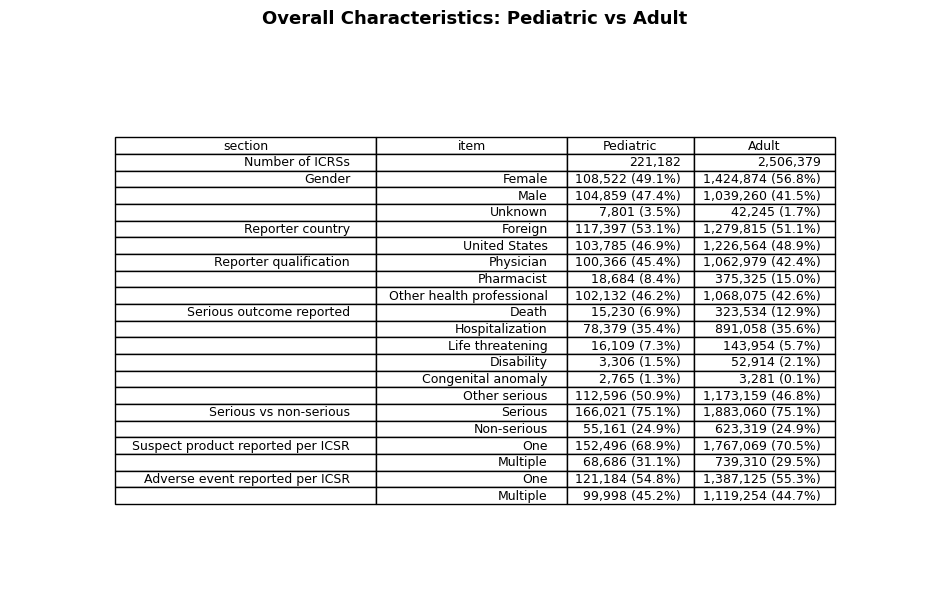

Saved: overview_adult_ped.png


In [24]:
# ── PNG: render table with matplotlib ──────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
ax.axis('off')
tbl = ax.table(
    cellText=display_df.values,
    colLabels=display_df.columns,
    loc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.auto_set_column_width(col=list(range(len(display_df.columns))))
plt.title('Overall Characteristics: Pediatric vs Adult', pad=20, fontsize=13, fontweight='bold')
plt.savefig('output/figures/overview_adult_ped.png', bbox_inches='tight', dpi=300)
plt.show()
print('Saved: overview_adult_ped.png')

In [25]:
# ── CSV: export summary_df (with all section labels intact) ────────────
summary_df.to_csv('output/csv/overall_characteristics_summary.csv', index=False)
print('Saved: overall_characteristics_summary.csv')

# Quick verification
check = pd.read_csv('output/csv/overall_characteristics_summary.csv')
print(f'Rows: {len(check)}  Cols: {check.shape[1]}')
print(check.to_string(index=False))


Saved: overall_characteristics_summary.csv
Rows: 21  Cols: 4
                          section                      item       Pediatric             Adult
                  Number of ICRSs                       NaN         221,182         2,506,379
                           Gender                    Female 108,522 (49.1%) 1,424,874 (56.8%)
                           Gender                      Male 104,859 (47.4%) 1,039,260 (41.5%)
                           Gender                   Unknown    7,801 (3.5%)     42,245 (1.7%)
                 Reporter country                   Foreign 117,397 (53.1%) 1,279,815 (51.1%)
                 Reporter country             United States 103,785 (46.9%) 1,226,564 (48.9%)
           Reporter qualification                 Physician 100,366 (45.4%) 1,062,979 (42.4%)
           Reporter qualification                Pharmacist   18,684 (8.4%)   375,325 (15.0%)
           Reporter qualification Other health professional 102,132 (46.2%) 1,068,075 (42.6%)